In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

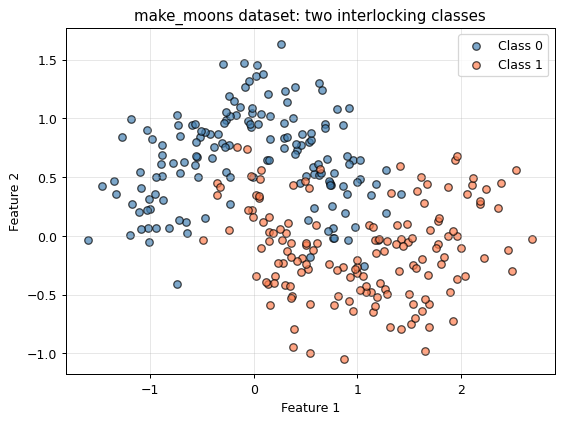

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Logistic regression accuracy (test): 0.883


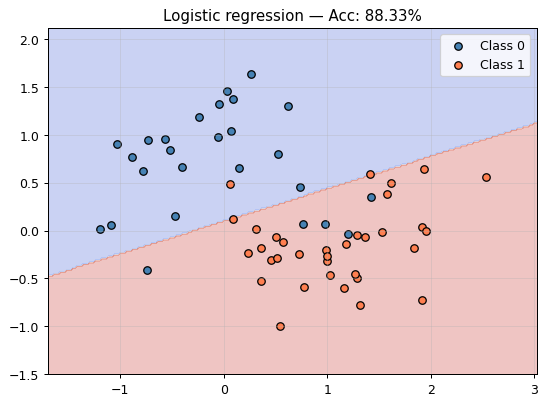

In [16]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

print(f'Logistic regression accuracy (test): {acc_logreg:.3f}')
plot_decision_boundary(logreg, X_test, y_test, f'Logistic regression — Acc: {acc_logreg:.2%}')

Logistic regression accuracy (test): 0.917


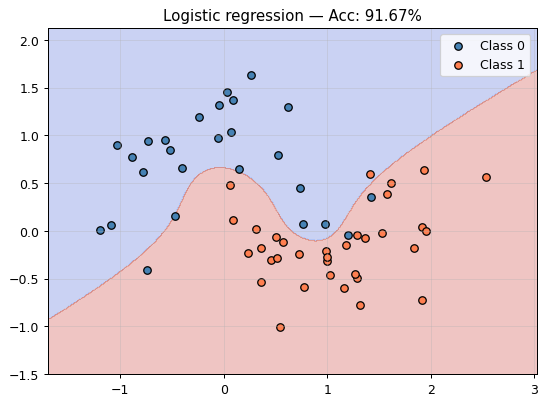

In [17]:

def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('clf',    LogisticRegressionCV(Cs=20, cv=5, max_iter=5000)),
])
logreg = GridSearchCV(logreg, {'poly__degree': [1, 2, 3, 4, 5]}, cv=5, n_jobs=-1)
logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

print(f'Logistic regression accuracy (test): {acc_logreg:.3f}')
plot_decision_boundary(logreg, X_test, y_test, f'Logistic regression — Acc: {acc_logreg:.2%}')